In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Passenger 1,male,21,1,1,TCKT10,51,C23,S
1,2,1,2,Passenger 2,female,22,2,0,TCKT20,52,B45,C
2,3,0,3,Passenger 3,male,23,0,1,TCKT30,53,E12,Q
3,4,1,1,Passenger 4,female,24,1,0,TCKT40,54,D56,S
4,5,0,2,Passenger 5,male,25,2,1,TCKT50,55,A10,C
5,6,1,1,Passenger 6,female,26,0,0,TCKT60,56,C23,S
6,7,0,2,Passenger 7,male,27,1,1,TCKT70,57,B45,C
7,8,1,3,Passenger 8,female,28,2,0,TCKT80,58,E12,Q
8,9,0,1,Passenger 9,male,29,0,1,TCKT90,59,D56,S
9,10,1,2,Passenger 10,female,30,1,0,TCKT100,60,A10,C


In [3]:
df = df.select_dtypes(include=['int64','float64','object'])
df = df.dropna()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled)
df['Cluster'] = clusters
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cluster
0,1,0,1,0,1,21,1,1,0,51,2,2,0
1,2,1,2,11,0,22,2,0,11,52,1,0,0
2,3,0,3,22,1,23,0,1,22,53,4,1,2
3,4,1,1,33,0,24,1,0,33,54,3,2,2
4,5,0,2,44,1,25,2,1,44,55,0,0,2


In [5]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)
pc1 = pca_data[:,0]
pc2 = pca_data[:,1]

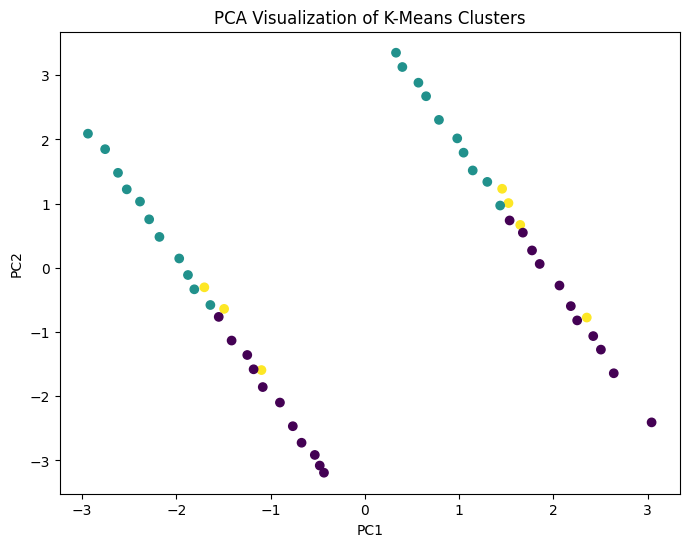

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(pc1, pc2, c=clusters)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization of K-Means Clusters')
plt.show()